In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# macOS-only fix: faiss and torch (pulled in later by sentence-transformers) each
# bundle their own OpenMP runtime; loading both aborts the process without this.
# Must be set before faiss/torch are imported anywhere in the notebook.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"  # silence the weight-loading progress bar noise

import faiss
import numpy as np


d = 384                      # embedding dim, e.g. all-MiniLM-L6-v2
xb = np.random.rand(100_000, d).astype("float32")  # your corpus embeddings

# --- exact baseline ---
index_flat = faiss.IndexFlatIP(d)     # inner product; use IndexFlatL2 for L2
index_flat.add(xb)

# --- HNSW: best default for RAG-scale corpora (10^4 - 10^7 vectors) ---
index_hnsw = faiss.IndexHNSWFlat(d, 32)     # M = 32 links per node
index_hnsw.hnsw.efConstruction = 200        # build-time search breadth
index_hnsw.add(xb)
index_hnsw.hnsw.efSearch = 64               # query-time search breadth (recall/latency knob)
# live per query knob

# --- IVF-PQ: for 10^7+ vectors where RAM is the constraint ---
quantizer = faiss.IndexFlatIP(d)
index_ivfpq = faiss.IndexIVFPQ(quantizer, d, 4096, 8, 8)  # nlist=4096, m=8 subquantizers, 8 bits
index_ivfpq.train(xb)
index_ivfpq.add(xb)
index_ivfpq.nprobe = 16                     # cells searched per query

query = np.random.rand(1, d).astype("float32")
D, I = index_hnsw.search(query, k=5)        # returns distances, indices of top-5

WARNING clustering 100000 points to 4096 centroids: please provide at least 159744 training points


In [2]:
from sentence_transformers import SentenceTransformer

# 15 real sentences across 3 clear topics -- these are the "correct" chunks a RAG
# system should retrieve. Everything else in the corpus is noise standing in for
# the rest of a big real-world corpus that's irrelevant to any given query.
docs = [
    "Gradient descent updates model weights by moving against the loss gradient.",
    "Backpropagation computes gradients layer by layer using the chain rule.",
    "Overfitting happens when a model memorizes training data instead of generalizing.",
    "Regularization techniques like dropout and weight decay reduce overfitting.",
    "Neural networks stack layers of weighted connections to learn representations.",

    "A primary key uniquely identifies each row in a relational database table.",
    "Indexes speed up database queries by avoiding full table scans.",
    "Normalization organizes tables to reduce data redundancy.",
    "SQL joins combine rows from two or more tables based on a related column.",
    "Transactions in a database guarantee atomicity and consistency of writes.",

    "A striker's job is to score goals and finish attacking chances.",
    "Midfielders control possession and link defense with attack.",
    "A well-organized defense limits the opponent's shots on goal.",
    "Set pieces like corners and free kicks create scoring opportunities.",
    "Goalkeepers must command their box and organize the defensive line.",
]

model = SentenceTransformer("all-MiniLM-L6-v2")
doc_vecs = model.encode(docs, normalize_embeddings=True).astype("float32")
d = doc_vecs.shape[1]

# pad with random unit vectors -- without this, 15 vectors is a trivial search.
# real embeddings cluster tightly by meaning; random vectors in 384 dims sit far
# apart from everything, so the true docs still stand out as genuine nearest neighbors.
rng = np.random.default_rng(0)
noise = rng.normal(size=(20_000, d)).astype("float32")
noise /= np.linalg.norm(noise, axis=1, keepdims=True)

xb = np.vstack([doc_vecs, noise])   # docs occupy indices [0, 15)
print(xb.shape)


/Users/monusingh/work-share/code-blogs-articles/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(20015, 384)


In [3]:
import faiss

# hand-labeled ground truth: for each question, which doc index should come back.
# this is the same shape as a real RAG eval set -- (query, id_of_the_chunk_that_should_be_retrieved)
queries = [
    ("How does backpropagation compute gradients?", 1),
    ("What does a database index do?", 6),
    ("What is a midfielder responsible for?", 11),
]
query_vecs = model.encode([q for q, _ in queries], normalize_embeddings=True).astype("float32")

# ground truth = exact, brute-force search over the FULL corpus (15 docs + 20,000 noise vectors)
index_flat = faiss.IndexFlatIP(d)
index_flat.add(xb)

k = 10
gt_D, gt_I = index_flat.search(query_vecs, k)

for (question, expected_idx), neighbors in zip(queries, gt_I):
    rank = list(neighbors).index(expected_idx) if expected_idx in neighbors else None
    print(f"{question!r:55s} expected doc {expected_idx:2d} -> found at rank {rank}")


'How does backpropagation compute gradients?'           expected doc  1 -> found at rank 0
'What does a database index do?'                        expected doc  6 -> found at rank 0
'What is a midfielder responsible for?'                 expected doc 11 -> found at rank 0


In [4]:
import time

# use every doc's own embedding as a query -- gives 15 query points instead of 3,
# enough to see a real recall curve instead of jumps of 33%
gt_D, gt_I = index_flat.search(doc_vecs, k)   # ground truth: true top-k for each doc, over the full corpus

index_hnsw = faiss.IndexHNSWFlat(d, 32)       # M = 32
index_hnsw.hnsw.efConstruction = 200
index_hnsw.add(xb)

ef_values = [4, 8, 16, 32, 64, 128, 256]
results = []

for ef in ef_values:
    index_hnsw.hnsw.efSearch = ef
    start = time.perf_counter()
    ann_D, ann_I = index_hnsw.search(doc_vecs, k)
    elapsed_ms = (time.perf_counter() - start) * 1000 / len(doc_vecs)

    # recall@k: of the true top-k neighbors, what fraction did HNSW actually return?
    hits = sum(len(set(gt_I[i]) & set(ann_I[i])) for i in range(len(doc_vecs)))
    recall = hits / (len(doc_vecs) * k)

    results.append((ef, recall, elapsed_ms))
    print(f"efSearch={ef:4d}  recall@{k}={recall:.3f}  avg query time={elapsed_ms:.3f} ms")


efSearch=   4  recall@10=0.980  avg query time=0.023 ms
efSearch=   8  recall@10=0.987  avg query time=0.026 ms
efSearch=  16  recall@10=0.993  avg query time=0.038 ms
efSearch=  32  recall@10=0.993  avg query time=0.065 ms
efSearch=  64  recall@10=0.993  avg query time=0.124 ms
efSearch= 128  recall@10=1.000  avg query time=0.236 ms
efSearch= 256  recall@10=1.000  avg query time=0.393 ms


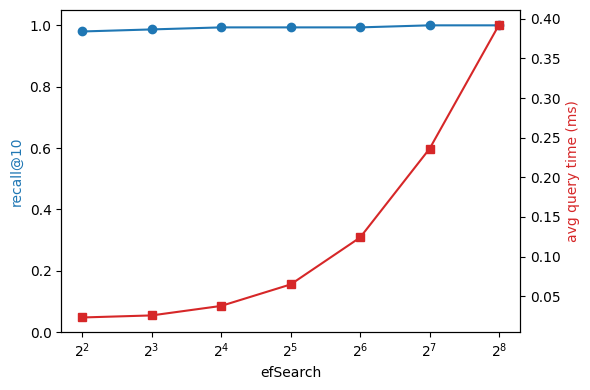

In [5]:
import matplotlib.pyplot as plt

efs, recalls, latencies = zip(*results)

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(efs, recalls, marker="o", color="tab:blue")
ax1.set_xlabel("efSearch")
ax1.set_ylabel("recall@10", color="tab:blue")
ax1.set_xscale("log", base=2)
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()
ax2.plot(efs, latencies, marker="s", color="tab:red")
ax2.set_ylabel("avg query time (ms)", color="tab:red")

fig.tight_layout()
plt.show()
